# IFN680 Assessment 3 — Aircraft Classification (Report Notebook)

**Student:** Karan Rooprai  **Student ID:** N12498122

This notebook **reproduces every figure and metric** used in the written report. It does **not**
retrain anything — it reloads the artefacts saved by `development.ipynb`
(`histories.pkl`, `best_model.pth`) and:

1. plots the learning curves for the baseline and the three experiments on shared graphs,
2. prints the validation-accuracy comparison table,
3. loads the best model, evaluates it on the untouched **test** set, and reports the required
   metric — **average per-class accuracy** — with a confusion matrix.

> Run `development.ipynb` first (it produces `histories.pkl` and `best_model.pth`), then run this
> notebook top-to-bottom.

## 1. Setup and load saved results

In [1]:
import os
import pickle
import shutil

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# The image set is not shipped inside the code archive (it is 158 MB); it is expected beside
# this notebook, exactly as FGVCAircraft_Subset20.zip unpacks. Check for it up front so a
# missing dataset fails here with a readable message rather than part-way through evaluation.
DATA_ROOT = 'FGVCAircraft_Subset20'
if not os.path.isdir(os.path.join(DATA_ROOT, 'test')):
    raise FileNotFoundError(
        f"Expected '{DATA_ROOT}/test' beside this notebook. Unzip FGVCAircraft_Subset20.zip "
        f"into {os.path.abspath('.')} and run this cell again.")

# Learning curves and validation scores written by development.ipynb
with open('histories.pkl', 'rb') as f:
    saved = pickle.load(f)
histories   = saved['histories']
class_names = saved['class_names']
num_classes = len(class_names)
print(f"Loaded histories for: {list(histories.keys())}")

# The 80/20 split development.ipynb trained against, recomputed here with the same seed so the
# split sizes quoted in the report come from this notebook like every other number.
probe = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, "trainval"))
tr_idx, va_idx = train_test_split(list(range(len(probe))), test_size=0.2,
                                  stratify=[label for _, label in probe.samples],
                                  random_state=42)
print(f"Trainval {len(probe)} images: {len(tr_idx)} train / {len(va_idx)} validation "
      f"(80/20 stratified)")


Using device: cpu
Loaded histories for: ['baseline', 'aug', 'finetune', 'adamw', 'best']
Trainval 1331 images: 1064 train / 267 validation (80/20 stratified)


## 2. Learning curves

The four models trained with a validation split — the baseline and the three experiments — are
overlaid on shared axes so their behaviour can be compared directly. Left: validation accuracy per
epoch. Right: training vs validation loss.

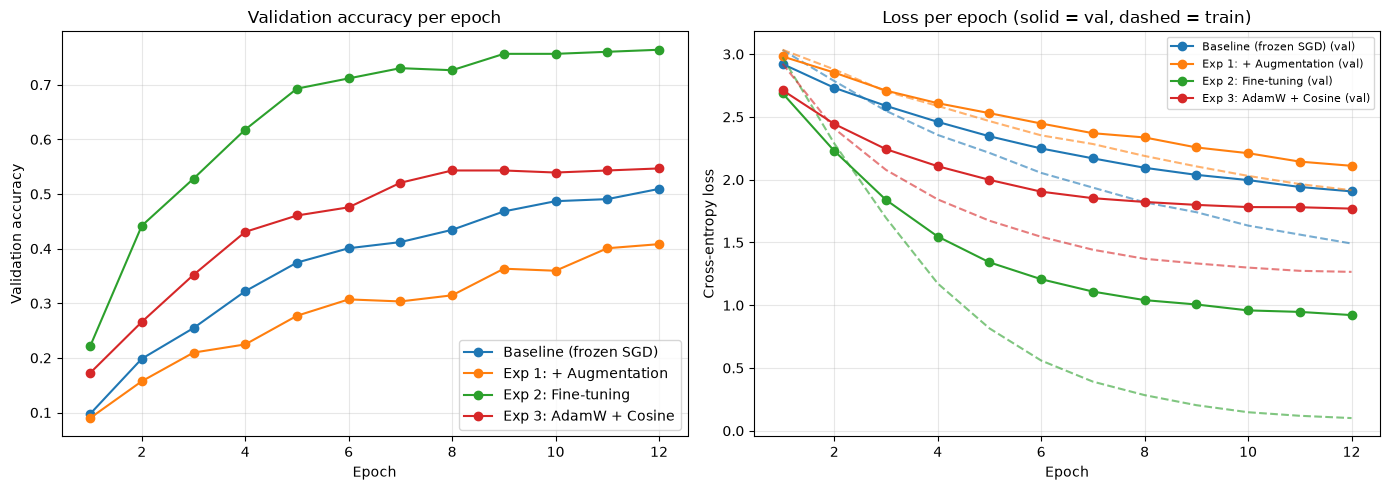

In [2]:
exp_keys = [('baseline', 'Baseline (frozen SGD)'),
            ('aug',      'Exp 1: + Augmentation'),
            ('finetune', 'Exp 2: Fine-tuning'),
            ('adamw',    'Exp 3: AdamW + Cosine')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: validation accuracy for all four on one graph
for key, label in exp_keys:
    epochs = range(1, len(histories[key]['val_acc']) + 1)
    ax1.plot(epochs, histories[key]['val_acc'], marker='o', label=label)
ax1.set_title('Validation accuracy per epoch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation accuracy')
ax1.grid(True, alpha=0.3); ax1.legend()

# Right: train (dashed) vs val (solid) loss for all four
for key, label in exp_keys:
    epochs = range(1, len(histories[key]['train_loss']) + 1)
    line, = ax2.plot(epochs, histories[key]['val_loss'], marker='o', label=f"{label} (val)")
    ax2.plot(epochs, histories[key]['train_loss'], linestyle='--',
             color=line.get_color(), alpha=0.6)
ax2.set_title('Loss per epoch (solid = val, dashed = train)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-entropy loss')
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.savefig('learning_curves.pdf', bbox_inches='tight')   # vector copy for the report
plt.show()

## 3. Validation-accuracy comparison

Best validation accuracy reached by each model. The gap to the baseline shows how much each
design change contributed.

In [3]:
baseline_acc = histories['baseline']['best_val_acc']
print(f"{'Model':<28}{'Best val acc':>14}{'Δ vs baseline':>16}")
print('-' * 58)
for key, label in exp_keys:
    acc = histories[key]['best_val_acc']
    delta = acc - baseline_acc
    tag = '' if key == 'baseline' else f"{delta:+.4f}"
    print(f"{label:<28}{acc:>14.4f}{tag:>16}")

Model                         Best val acc   Δ vs baseline
----------------------------------------------------------
Baseline (frozen SGD)               0.5094                
Exp 1: + Augmentation               0.4082         -0.1011
Exp 2: Fine-tuning                  0.7640         +0.2547
Exp 3: AdamW + Cosine               0.5468         +0.0375


## 4. Best model — evaluation on the test set

The best model — a fine-tuned ResNet-18 trained with AdamW and Cosine-Annealing on
**un-augmented** images, retrained on the whole of `trainval` — is reloaded from
`best_model.pth` and evaluated **once** on the held-out test set.

Augmentation is deliberately *not* part of this configuration: it was the one experiment that
lowered validation accuracy, so it is not carried into the final model.

Because the model was refit on the entire `trainval` pool, no validation split survives it, so
every number below is measured on the test set and on nothing else. The required metric is
**average per-class accuracy** — the mean of the twenty per-class recall values, computed with
`balanced_accuracy_score` — which weights every aircraft type equally rather than letting the
larger or easier classes dominate. The pass target is **> 0.75**.


In [4]:
# Rebuild the architecture and load the weights saved by development.ipynb
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds  = (0.229, 0.224, 0.225)

# Identical preprocessing to the evaluation transform used during development: resize to the
# 224x224 the pretrained backbone expects, then normalise with the ImageNet statistics.
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    # antialias is pinned rather than left to the default. Resize applied to a tensor (which is
    # what it is here, since ToTensor runs first) only antialiases by default on newer
    # torchvision; on an older one the same code silently resamples differently and the model
    # scores several points lower. Pinning it makes the result independent of the version.
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

# Jupyter writes a .ipynb_checkpoints folder wherever a notebook is saved. If one lands inside the
# test folder, ImageFolder reads it as a twenty-first class and every label shifts. Remove any
# before building the dataset; only Jupyter's own auto-saved copies are ever touched.
for root, dirs, _ in os.walk(DATA_ROOT):
    for d in list(dirs):
        if d == '.ipynb_checkpoints':
            shutil.rmtree(os.path.join(root, d))
            print(f"Removed stray {os.path.join(root, d)}")

test_dataset = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'),
                                                transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
# The saved class order must match the folder order, or every prediction is silently mislabelled.
assert test_dataset.classes == class_names, "test class order differs from the saved class order"
print(f"Test images: {len(test_dataset)} across {len(test_dataset.classes)} classes")

# weights=None: the architecture only, since every weight is about to be overwritten.
model = torchvision.models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
# weights_only=True loads plain tensors and executes nothing from the checkpoint file.
model.load_state_dict(torch.load('best_model.pth', map_location=device, weights_only=True))
model = model.to(device)
model.eval()   # evaluation mode: no dropout, no batch-norm statistic updates
print("Loaded best_model.pth")


Test images: 669 across 20 classes


Loaded best_model.pth


In [5]:
all_labels, all_preds = [], []
with torch.no_grad():                      # no gradients needed, and it halves the memory
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

# Required metric: average per-class accuracy (= the mean of the per-class recalls)
avg_per_class_acc = balanced_accuracy_score(all_labels, all_preds)
overall_acc = (all_preds == all_labels).mean()
# Macro F1 additionally penalises a class the model over-predicts, which plain recall does not.
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Overall test accuracy        : {overall_acc:.4f}")
print(f"Average per-class accuracy   : {avg_per_class_acc:.4f}   (target > 0.75)")
print(f"Macro-averaged F1            : {macro_f1:.4f}")
print("PASS" if avg_per_class_acc > 0.75 else "BELOW TARGET")

# The final model's own training accuracy, from the curves development.ipynb saved. The gap
# between it and test accuracy is what over-fitting looks like as a number.
final_train_acc = histories["best"]["train_acc"][-1]
print(f"Final model training accuracy: {final_train_acc:.2f}"
      f"   gap to test: {final_train_acc - overall_acc:.2f}")


Overall test accuracy        : 0.8161
Average per-class accuracy   : 0.8163   (target > 0.75)
Macro-averaged F1            : 0.8164
PASS
Final model training accuracy: 1.00   gap to test: 0.18


### 4.1 Confusion matrix and per-class accuracy

The confusion matrix shows where the model confuses visually similar aircraft; the per-class
accuracy list identifies the weakest classes.

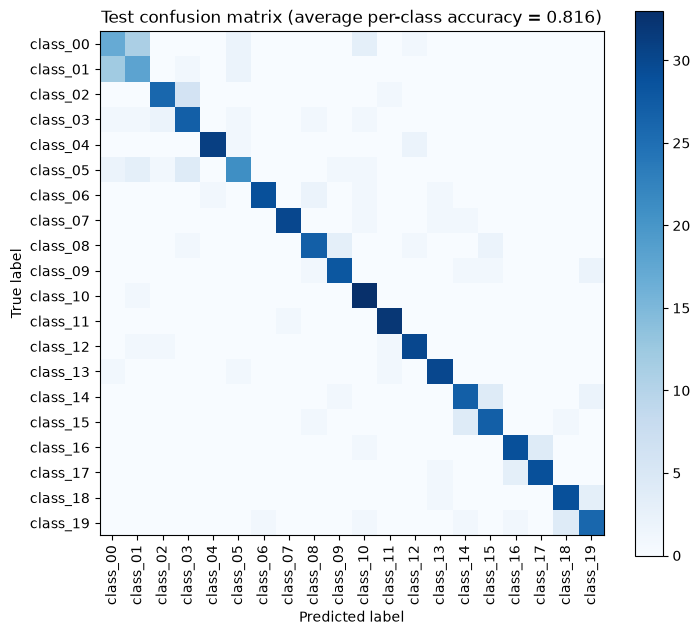

In [6]:
cm = confusion_matrix(all_labels, all_preds)

# include_values=False: at 20x20 the 400 per-cell counts are unreadable at report size, so the
# matrix is shown as a heatmap and the exact confusions are printed underneath instead.
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation='vertical', colorbar=True, cmap='Blues', include_values=False)
ax.set_title(f'Test confusion matrix (average per-class accuracy = {avg_per_class_acc:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.savefig('confusion_matrix.pdf', bbox_inches='tight')   # vector copy for the report
plt.show()


In [7]:
# Per-class accuracy = correct predictions for that class / images of that class
per_class = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class)

print(f"{'Class':<12}{'Accuracy':>10}")
print('-' * 22)
for i in order:
    print(f"{class_names[i]:<12}{per_class[i]:>10.3f}")
print('-' * 22)
print(f"{'MEAN':<12}{per_class.mean():>10.3f}")

# Counted here rather than in the report, so the figure quoted there cannot drift from the data.
STRONG = 0.87
print()
print(f"Classes scoring above {STRONG:.2f}: "
      f"{int((per_class > STRONG).sum())} of {num_classes}")
print(f"Weakest class: {class_names[order[0]]} at {per_class[order[0]]:.3f}")


Class         Accuracy
----------------------
class_00         0.500
class_01         0.545
class_05         0.636
class_19         0.765
class_02         0.788
class_03         0.794
class_14         0.794
class_08         0.794
class_15         0.818
class_09         0.848
class_16         0.853
class_06         0.853
class_18         0.879
class_17         0.879
class_13         0.909
class_07         0.909
class_12         0.909
class_04         0.912
class_11         0.970
class_10         0.971
----------------------
MEAN             0.816

Classes scoring above 0.87: 8 of 20
Weakest class: class_00 at 0.500


### 4.2 Where the errors actually fall

The heatmap shows *that* a few classes are weak; these counts show *which* aircraft they are
confused with, which is what makes the failure interpretable.


In [8]:
# Which aircraft the model actually mistakes for which. The report quotes these counts, so
# they are printed rather than read off the heatmap by eye.
off = cm.copy()
np.fill_diagonal(off, 0)          # keep only the mistakes
pairs = sorted(((off[i, j], i, j)
                for i in range(num_classes) for j in range(num_classes) if off[i, j] > 0),
               reverse=True)

print(f"{'True class':<12}{'Predicted as':<14}{'Images':>7}")
print('-' * 33)
for n, i, j in pairs[:8]:
    print(f"{class_names[i]:<12}{class_names[j]:<14}{n:>7d}")


True class  Predicted as   Images
---------------------------------
class_01    class_00           12
class_00    class_01           11
class_02    class_03            6
class_19    class_18            4
class_16    class_17            4
class_15    class_14            4
class_14    class_15            4
class_05    class_03            4
